In [39]:
import numpy as np 
import matplotlib.pyplot as plt

In [40]:
def PhysicalPendulum (dt, g, l, theta0, q, FD, omegaD) :
    # creating a range for time from 0 to 150+dt
    t = np.arange(0, 150+dt, dt) 
    # creating a range of angular velocity (omega) and angular displacement (theta) with all zeroes and have length = time range (
    
    omega = np.zeros(len(t))
    theta = np.zeros(len(t))      
    # setting the initial angular displacement
    theta[0] = theta0

    # Euler Cromer method
    for i in range(len(t)-1): 
        omega[i+1] = omega[i] - ((g/l)*np.sin(theta[i]) + q*omega[i] - FD*np.sin(omegaD*t[i]))*dt
        theta[i+1] = theta[i] + dt*omega[i+1]

        # if angular displacement < pi, + 2pi
        if theta[i+1] < -3.14: 
            theta[i+1]+=2*3.14

        #if angular displacent > pi, -2pi
        if theta[i+1] > 3.14:
            theta[i+1]-=2*3.14
        
        t[i+1] = t[i] + dt

    return t, theta, omega

In [41]:
g = 9.8 
dt = 0.04
l=g
theta0 = 0.2
q = 0.5
omegaD = 2/3 # driving force, period of driving force = 3pi

t1, theta1, omega1 = PhysicalPendulum(dt, g, l, theta0, q, 1.35, omegaD) 
t2, theta2, omega2 = PhysicalPendulum(dt, g, l, theta0, q, 1.44, omegaD) 
t3, theta3, omega3 = PhysicalPendulum(dt, g, l, theta0, q, 1.465, omegaD) 


[Text(0, 0.5, '$\\theta$ (radians)'), Text(0.5, 0, 'time(s)')]

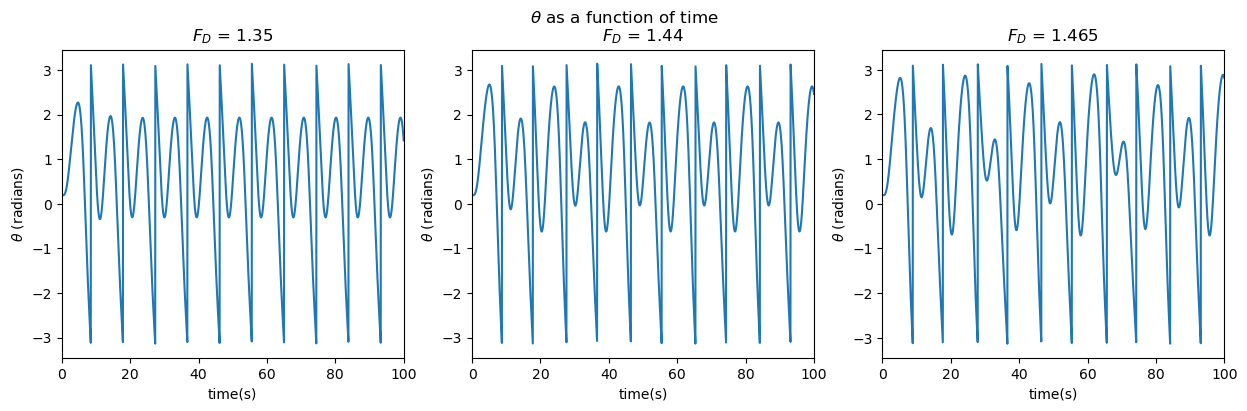

In [48]:

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))

fig.suptitle(r'$\theta$ as a function of time')
ax1.set_xlim(0,100)
ax2.set_xlim(0,100)
ax3.set_xlim(0,100)

ax1.plot(t1, theta1)
ax2.plot(t2, theta2)
ax3.plot(t3, theta3) 

ax1.set_title(r"$F_D$ = 1.35")
ax2.set_title(r"$F_D$ = 1.44")
ax3.set_title(r"$F_D$ = 1.465")

ax1.set(ylabel=r'$\theta$ (radians)', xlabel=r'time(s)')
ax2.set(ylabel=r'$\theta$ (radians)', xlabel=r'time(s)')
ax3.set(ylabel=r'$\theta$ (radians)', xlabel=r'time(s)')


## Bifurcation 

In [49]:

def PoincarePhysicalPendulum (tf, dt, g, l, theta0, q, FD, omegaD) :
    
    num_plotpoints = int(tf/dt) 

    # creating a range of angular velocity (omega) and angular displacement (theta) with all zeroes and have length = number of plot points
    # note to self: try to use 2 dimensional arrays next time
    omega = np.zeros(num_plotpoints)
    theta = np.zeros(num_plotpoints)   
    time = np.zeros (num_plotpoints) 
    
    # setting the initial angular displacement
    theta[0] = theta0
    omega[0] = 0

    poincare_theta, poincare_omega = [], []

    # Driving period
    T = 2*np.pi/omegaD

    for i in range (num_plotpoints-1): 
        time[i+1] = time[i] + dt 
    
        # Euler Cromer method
        omega[i+1] = omega[i] - ((g/l)*np.sin(theta[i]) + q*omega[i] - FD*np.sin(omegaD*time[i]))*(dt)
        theta[i+1] = theta[i] + omega[i+1]*dt
    
        # Keep theta within [-pi, pi]
        if theta[i+1] < -np.pi: 
            theta[i+1]+=2*np.pi
        elif theta[i+1] > np.pi:
            theta[i+1]-=2*np.pi

        # check if t is within dt/2 of a multiple of T
        if abs((time[i+1] % T) - 0) < dt/2:
            poincare_theta.append(theta[i+1])
            poincare_omega.append(omega[i+1])

    return poincare_theta, poincare_omega

In [50]:
FD_start = 1.35
FD_end = 1.5
FD_amount = 1000


FD = np.linspace(FD_start, FD_end, FD_amount) # driving force
theta_FD = [] 
omega_FD = []
FD_plot = []

for n in range(len(FD)) : 
    poincare_theta, _ = PoincarePhysicalPendulum (7000, 0.04,9.8,9.8, 0.2 ,0.5, FD[n] ,2/3)
    theta_FD.extend(poincare_theta[300:]) # wait after 300 driving periods until initial transient have decayed away
    for m in range(len(poincare_theta[300:])): 
        FD_plot.append(FD[n])


In [51]:
p = np.arange(10) 

g = [ ] 
f = [ ]

for n in range(len(FD)) : 
    g.extend(p) 
    for m in range(len(p[:3])) : 
        f.append(FD[n]) 
#f

<function matplotlib.pyplot.show(close=None, block=None)>

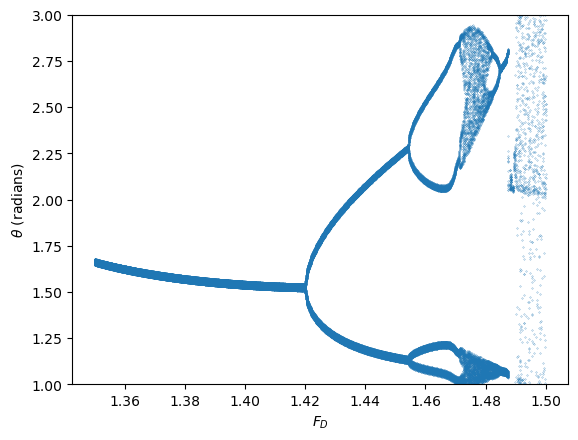

In [52]:
plt.plot(FD_plot, theta_FD, 'o', markersize=0.2) 
plt.ylim(1,3)

plt.xlabel(r'$F_D$') 
plt.ylabel(r'$\theta$ (radians)') 
plt.show